# 1. Base de datos

Este capítulo cubre la sección 1 de la guía: definición del problema, justificación y fuente del
dataset, diccionario de variables, estructura de los datos, reserva del conjunto de prueba,
tamaño de la muestra, calidad de los datos y consideraciones éticas.

## 1.1 Definición del problema

### El problema

La demencia es una de las principales causas de discapacidad y dependencia en adultos mayores, y
buena parte de sus casos es prevenible: la Comisión Lancet 2024 estimó que cerca del 45 % de los
casos se asocia a 14 factores de riesgo modificables (Livingston et al., 2024). Para prevenir hace
falta detectar a tiempo, y la dificultad cognitiva subjetiva, es decir la percepción de la propia
persona de que tiene problemas para recordar o concentrarse, es una de las señales más tempranas:
quienes la reportan tienen aproximadamente el doble de riesgo de desarrollar demencia (RR ≈ 2,07;
Mitchell et al., 2014; RR ≈ 2,12; Wang et al., 2021). Sin embargo esta señal rara vez se evalúa de
forma sistemática, mientras que la información sobre factores de riesgo (hipertensión, diabetes,
depresión, audición, tabaquismo, escolaridad, antecedente de ACV) sí se registra de forma rutinaria.
No se sabe con claridad cuánta información aporta ese perfil de factores de riesgo para anticipar la
dificultad cognitiva, y ahí está el espacio que este proyecto busca explorar.

### Pregunta de investigación

¿Qué tan bien predicen los factores de riesgo modificables de demencia y el antecedente de ACV la
presencia de dificultad cognitiva subjetiva en adultos?

Es un problema de clasificación binaria supervisada (ruta A de la guía): la variable objetivo es
categórica, presencia o ausencia de dificultad cognitiva.

### Objetivo general

Desarrollar y evaluar un modelo de clasificación que estime la probabilidad de dificultad cognitiva
subjetiva a partir de los factores de riesgo modificables y el antecedente de ACV, con datos de la
National Health Interview Survey (NHIS) 2022-2023.

### Objetivos específicos

1. Caracterizar la prevalencia de dificultad cognitiva subjetiva y su asociación con cada factor de
   riesgo, reportando tamaños de efecto.
2. Identificar y excluir las variables que constituyan fuga de información.
3. Entrenar una regresión logística como modelo base y compararla con un clasificador trivial
   mediante PR-AUC, ROC-AUC, recall, F1 y calibración, con intervalos de confianza bootstrap.
4. Interpretar la contribución de cada factor mediante odds ratios, con énfasis en el ACV.

### Alcance

Los datos son transversales, así que el modelo no predice un deterioro futuro: estima qué tan bien
el perfil de factores de riesgo identifica a quienes hoy reportan dificultad cognitiva. Es, en el
fondo, una prueba de concepto sobre el valor predictivo de esa información, más que un modelo de
pronóstico.

## 1.2 Justificación de la selección del dataset

- Pertinencia: la NHIS incluye la pregunta de cognición del Washington Group Short Set, un
  instrumento estandarizado internacionalmente, y la mayoría de los factores de riesgo de la
  Comisión Lancet 2024 medidos con las mismas preguntas en 2022 y 2023.
- Tamaño: más de 56 000 adultos, muy por encima del mínimo de 20 000 observaciones que pide la
  guía, y cada fila corresponde a una persona distinta.
- Datos reales y oficiales: encuesta nacional del National Center for Health Statistics (NCHS/CDC),
  con documentación pública completa, incluidos codebooks y descripción del diseño.
- Acceso libre e inmediato: los archivos de uso público se descargan sin registro.
- Dificultad adecuada: es un fenómeno multifactorial y autorreportado, así que no se espera un
  desempeño trivialmente alto, lo que deja margen para mejorar con modelos más complejos en las
  siguientes entregas.

## 1.3 Fuente de los datos y licencia

- Fuente: National Center for Health Statistics. National Health Interview Survey, 2022 y 2023.
  Sample Adult Interview, public-use data files. Hyattsville, MD: CDC.
  - 2022: <https://www.cdc.gov/nchs/nhis/documentation/2022-nhis.html> (`adult22csv.zip`)
  - 2023: <https://www.cdc.gov/nchs/nhis/documentation/2023-nhis.html> (`adult23csv.zip`)
- Licencia y condiciones de uso: son datos de uso público producidos por una agencia del gobierno
  federal de EE. UU., sin restricciones de derechos de autor. Las condiciones de uso del NCHS exigen
  citar la fuente y prohíben cualquier intento de identificar a los participantes o de vincular los
  datos con otras fuentes con ese fin.
- Documentación usada: codebooks y resúmenes de variables del Sample Adult File 2022 y 2023.

## 1.4 Carga de los datos y criterios de inclusión

Los archivos se leen directamente desde los `.zip` descargados del CDC (carpeta `data/raw/`). Las
recodificaciones, como los códigos de no respuesta 7, 8 y 9 que pasan a faltante, las etiquetas de
categorías y la agrupación de los 10 niveles educativos en 5, provienen del codebook y no de los
datos mismos, así que aplicarlas antes de la partición no introduce fuga de información. El código
está en `src/utils.py`.

Los criterios de inclusión son:
1. Adultos de 18 años o más, de los archivos 2022 y 2023.
2. Se excluyen las entrevistas respondidas por un informante o proxy, porque el constructo de
   interés es la dificultad percibida por la propia persona.
3. Se excluyen los registros cuya variable objetivo quedó con código de no respuesta.


In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import *

estilo_graficos()
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
crudo = cargar_crudos()
print(f"Archivo crudo combinado: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas seleccionadas")
datos, flujo = construir_dataset(crudo)
flujo["excluidos"] = (-flujo["registros"].diff()).fillna(0).astype(int)
display(flujo)
print(f"Dataset analítico: {datos.shape[0]:,} adultos x {datos.shape[1]} columnas")

Archivo crudo combinado: 57,173 filas x 26 columnas seleccionadas


,paso,registros,excluidos
0,Adultos en los archivos 2022 + 2023,57173,0
1,Excluye entrevistas respondidas por un informa...,56148,1025
2,Excluye objetivo con código de no respuesta (7...,56129,19


Dataset analítico: 56,129 adultos x 25 columnas


```{figure} ../images/flujo_muestra.png
:name: fig-flujo-muestra
:width: 460px

Flujo de la muestra: de los adultos entrevistados en 2022-2023 al conjunto de entrenamiento y
prueba.
```

De los 57 173 adultos entrevistados en 2022 y 2023 quedan 56 129 en el dataset analítico, como
resume la figura anterior. La exclusión más grande, 1 025 registros o un 1,8 %, corresponde a las
entrevistas respondidas por un informante. Es una decisión conceptual: la pregunta objetivo mide la
dificultad percibida por la propia persona, y un familiar o cuidador responde desde otra
perspectiva. El costo es un sesgo de selección conocido, porque esas personas no pudieron responder
por una condición física o mental y probablemente concentran los casos de deterioro más severo (se
retoma en la sección 1.9.6). Solo 19 registros más se pierden por no respuesta en la variable
objetivo.


## 1.5 Diccionario de variables

La selección de predictoras sigue el marco de los 14 factores de riesgo modificables de la Comisión
Lancet 2024, más el antecedente de ACV, que es la exposición de interés, y tres variables
sociodemográficas de ajuste: edad, sexo y raza o etnia. También se conservan algunas variables que
**no** se usan como predictoras: unas solo sirven para el EDA y otras entran en la auditoría de fuga
de datos (sección 2.5).


In [3]:
display(DICCIONARIO.style.hide(axis="index").set_properties(**{"text-align": "left"}))

variable,variable_nhis,rol,tipo,unidad_categorias,significado,factor_lancet_2024
dificultad_cognitiva,COGMEMDFF_A,Objetivo,Binaria,"0 = ninguna; 1 = alguna, mucha o no puede",¿Tiene dificultad para recordar o concentrarse? (Washington Group),—
edad,AGEP_A,Predictora,Numérica discreta,Años (18-84; 85 = 85 o más),Edad del adulto entrevistado,No (confusor)
sexo,SEX_A,Predictora,Nominal binaria,Hombre / Mujer,Sexo del adulto,No (confusor)
raza_etnia,HISPALLP_A,Predictora,Nominal (7),Grupos raciales y origen hispano,Raza/etnia autodeclarada,No (confusor)
educacion,EDUCP_A,Predictora,Ordinal (5),Menos que secundaria … Posgrado,Máximo nivel educativo alcanzado (agrupado a partir de 10 niveles),Sí: baja escolaridad
hipertension,HYPEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con hipertensión,Sí: hipertensión
colesterol_alto,CHLEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con colesterol alto,Sí: colesterol LDL alto
diabetes,DIBEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con diabetes,Sí: diabetes
acv,STREV_A,Predictora,Binaria,Sí / No,Alguna vez le dijeron que tuvo un ACV,No (exposición de interés)
depresion_dx,DEPEV_A,Predictora,Binaria,Sí / No,Alguna vez diagnosticado con depresión,Sí: depresión


### Factores de la Comisión Lancet 2024 no disponibles en ambos años

De los 14 factores, la NHIS 2022-2023 permite medir 9 con preguntas idénticas en ambos años:
escolaridad, hipertensión, colesterol, diabetes, depresión, pérdida auditiva, pérdida visual,
tabaquismo y obesidad. El consumo de alcohol y la inactividad física solo se preguntaron en 2022, y
el aislamiento social, el traumatismo craneoencefálico y la contaminación del aire no están
disponibles con una medición comparable. Incluir los factores de un solo año obligaría a descartar
la mitad de la muestra o a imputar un año completo, así que se declaran como limitación del
proyecto.


## 1.6 Estructura de los datos

In [4]:
estructura = pd.DataFrame({
    "característica": ["Unidad de observación", "Nivel de agregación", "Tipo de datos",
                       "Adultos por hogar", "Hogares repetidos dentro de un año",
                       "Componente temporal", "Componente espacial"],
    "valor": ["Un adulto seleccionado al azar en cada hogar", "Individual (sin agregación)",
              "Transversal: dos muestras anuales independientes (2022 y 2023)",
              "1 (por diseño de la encuesta)",
              int(datos.duplicated(["anio", "id_hogar"]).sum()),
              "Solo año y trimestre de entrevista (no es serie de tiempo)",
              "No hay coordenadas; solo región censal (no usada)"]})
display(estructura.style.hide(axis="index"))
print(datos.groupby("anio").size().rename("adultos").to_frame().T)

característica,valor
Unidad de observación,Un adulto seleccionado al azar en cada hogar
Nivel de agregación,Individual (sin agregación)
Tipo de datos,Transversal: dos muestras anuales independientes (2022 y 2023)
Adultos por hogar,1 (por diseño de la encuesta)
Hogares repetidos dentro de un año,0
Componente temporal,Solo año y trimestre de entrevista (no es serie de tiempo)
Componente espacial,No hay coordenadas; solo región censal (no usada)


anio      2022   2023
adultos  27153  28976


Los datos son transversales: cada fila es un adulto distinto, medido una sola vez, sin agregación,
y no hay hogares repetidos dentro de un año. Los dos años son muestras independientes, no un
seguimiento de las mismas personas. Esto tiene dos consecuencias para el modelado. La primera es que
la validación no necesita agruparse por entidad, así que no hace falta usar `GroupKFold`. La segunda
es que no aplican las rutas temporal ni espacial de la guía. El año se usa solo para estratificar la
partición y para verificar que la variable objetivo no cambie entre 2022 y 2023 (sección 2.1).


## 1.7 Reserva del conjunto de prueba

Siguiendo la guía, el conjunto de prueba se reserva antes de tomar cualquier decisión basada en los
datos, ya sea imputación, agrupación de categorías, umbrales o selección de variables. La partición
es 80/20, estratificada por la variable objetivo y por el año, para conservar en ambos conjuntos la
proporción de casos positivos y la mezcla de años. Como hay un solo adulto por hogar y los
identificadores de hogar son aleatorios por año, no hay entidades repetidas que obliguen a usar
`GroupKFold`. A partir de aquí, todo el EDA se calcula únicamente con el conjunto de entrenamiento.


In [5]:
train, test = dividir(datos)
DIR_PROC.mkdir(parents=True, exist_ok=True)
train.to_csv(DIR_PROC / "train.csv", index=False)
test.to_csv(DIR_PROC / "test.csv", index=False)
datos.to_csv(DIR_PROC / "nhis_cognicion_2022_2023.csv", index=False)

resumen = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba", "Total"],
    "n": [len(train), len(test), len(datos)],
    "positivos": [train[OBJETIVO].sum(), test[OBJETIVO].sum(), datos[OBJETIVO].sum()],
    "prevalencia": [train[OBJETIVO].mean(), test[OBJETIVO].mean(), datos[OBJETIVO].mean()],
    "% de 2023": [(train.anio == 2023).mean(), (test.anio == 2023).mean(), (datos.anio == 2023).mean()]})
display(resumen.style.hide(axis="index").format({"n": "{:,}", "positivos": "{:,}",
                                                  "prevalencia": "{:.2%}", "% de 2023": "{:.2%}"}))

conjunto,n,positivos,prevalencia,% de 2023
Entrenamiento,"44,903","9,253",20.61%,51.62%
Prueba,"11,226","2,313",20.60%,51.62%
Total,"56,129","11,566",20.61%,51.62%


## 1.8 Tamaño de la muestra

In [6]:
n, p_vars = len(datos), len(PREDICTORAS)
pre_tmp = __import__("src.preprocesamiento", fromlist=["x"]).construir_preprocesador()
p_cols = pre_tmp.fit(train[PREDICTORAS]).transform(train[PREDICTORAS].head()).shape[1]
tam = pd.DataFrame({
    "indicador": ["Observaciones (total)", "Observaciones (entrenamiento)", "Predictoras (variables)",
                  "Columnas tras codificación one-hot y splines", "Relación n/p (entrenamiento / columnas)",
                  "Casos clase 1: con dificultad cognitiva", "Casos clase 0: sin dificultad cognitiva",
                  "Casos clase 1 en entrenamiento", "Entidades independientes (adultos = hogares)"],
    "valor": [f"{n:,}", f"{len(train):,}", p_vars, p_cols, f"{len(train) / p_cols:,.0f}",
              f"{datos[OBJETIVO].sum():,}", f"{(datos[OBJETIVO] == 0).sum():,}",
              f"{train[OBJETIVO].sum():,}", f"{len(datos):,} (un adulto por hogar)"]})
display(tam.style.hide(axis="index"))

indicador,valor
Observaciones (total),"56,129"
Observaciones (entrenamiento),"44,903"
Predictoras (variables),14
Columnas tras codificación one-hot y splines,35
Relación n/p (entrenamiento / columnas),"1,283"
Casos clase 1: con dificultad cognitiva,"11,566"
Casos clase 0: sin dificultad cognitiva,"44,563"
Casos clase 1 en entrenamiento,"9,253"
Entidades independientes (adultos = hogares),"56,129 (un adulto por hogar)"


La muestra supera con holgura el mínimo de 20 000 observaciones que pide la guía: 56 129 en total,
44 903 para entrenar. Tras codificar las variables quedan 35 columnas, así que la relación n/p es
de más de 1 000 observaciones por parámetro y el riesgo de sobreajuste por dimensionalidad es bajo.
La clase minoritaria, es decir quienes reportan dificultad cognitiva, tiene 11 566 casos en total y
9 253 en entrenamiento, un número suficiente para estimar métricas e intervalos de confianza
estables. Como además hay un solo adulto por hogar, el número de entidades independientes coincide
con el número de filas, así que el tamaño efectivo de la muestra no está inflado por medidas
repetidas.


## 1.9 Calidad de los datos (conjunto de entrenamiento)

### 1.9.1 Valores faltantes: magnitud y patrón

In [7]:
import missingno as msno

cols_calidad = PREDICTORAS + ["imc"]
faltantes = (train[cols_calidad].isna().agg(["sum", "mean"]).T
             .rename(columns={"sum": "faltantes", "mean": "proporción"})
             .sort_values("proporción", ascending=False))
faltantes["faltantes"] = faltantes["faltantes"].astype(int)
display(faltantes.style.format({"proporción": "{:.2%}"}).bar(subset="proporción", color="#f4a582"))
print(f"Filas con al menos un faltante en las predictoras: {train[PREDICTORAS].isna().any(axis=1).mean():.2%}")

,faltantes,proporción
imc,3804,8.47%
tabaquismo,1341,2.99%
frecuencia_depresion,1013,2.26%
imc_categoria,996,2.22%
educacion,206,0.46%
colesterol_alto,123,0.27%
edad,106,0.24%
hipertension,70,0.16%
depresion_dx,66,0.15%
acv,54,0.12%


Filas con al menos un faltante en las predictoras: 6.18%


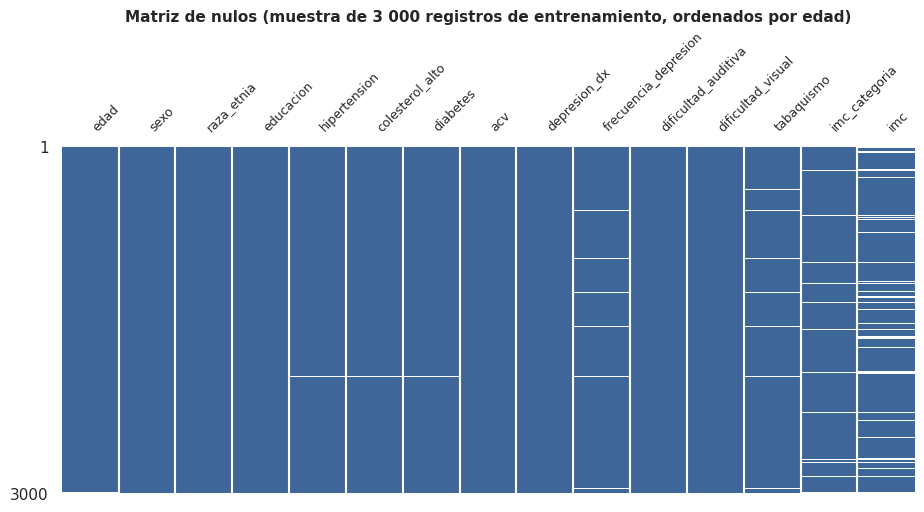

In [8]:
muestra = train[cols_calidad].sample(3000, random_state=SEED).sort_values("edad")
ax = msno.matrix(muestra, figsize=(11, 4.5), fontsize=9, sparkline=False, color=(0.25, 0.4, 0.6))
ax.set_title("Matriz de nulos (muestra de 3 000 registros de entrenamiento, ordenados por edad)", fontsize=11)
plt.show()

Los faltantes son escasos: ninguna predictora supera el 3 % y solo el 6,2 % de las filas tiene al
menos un dato ausente. Los más frecuentes son tabaquismo (3,0 %), frecuencia de depresión (2,3 %) y
categoría de IMC (2,2 %). La matriz de nulos no muestra bloques de filas con muchos faltantes a la
vez ni un patrón asociado a la edad, así que los huecos están dispersos y casi nunca coinciden en
la misma persona. El IMC numérico tiene 8,5 % de faltantes, casi cuatro veces más que la categoría
de IMC. La explicación aparece en la sección siguiente y es justamente la razón para usar la
categoría, y no el valor numérico, como predictora.


### 1.9.2 Mecanismo de los faltantes (MCAR, MAR o MNAR)

La prueba de Little supone variables continuas con distribución normal multivariada, algo que no se
cumple aquí porque casi todas las variables son categóricas. Por eso se usa la alternativa que
permite la guía: comparar los registros completos con los incompletos y modelar la probabilidad de
faltante en función de variables observadas. Si el faltante depende de variables observadas, el
mecanismo no es MCAR.


In [9]:
from scipy import stats

incompleto = train[PREDICTORAS].isna().any(axis=1)
comp = pd.DataFrame({
    "completos": [train.loc[~incompleto, OBJETIVO].mean(), train.loc[~incompleto, "edad"].median(),
                  (train.loc[~incompleto, "edad"] >= 65).mean(), (train.loc[~incompleto, "sexo"] == "Mujer").mean()],
    "incompletos": [train.loc[incompleto, OBJETIVO].mean(), train.loc[incompleto, "edad"].median(),
                    (train.loc[incompleto, "edad"] >= 65).mean(), (train.loc[incompleto, "sexo"] == "Mujer").mean()]},
    index=["Prevalencia de dificultad cognitiva", "Edad mediana", "Proporción de 65+ años", "Proporción de mujeres"])

tab = pd.crosstab(incompleto, train[OBJETIVO])
chi2, p_chi, _, _ = stats.chi2_contingency(tab)
u = stats.mannwhitneyu(train.loc[incompleto, "edad"].dropna(), train.loc[~incompleto, "edad"].dropna())
r_rb = 1 - 2 * u.statistic / (incompleto.sum() * (~incompleto).sum())
display(comp)
print(f"Objetivo vs. incompleto: chi2 = {chi2:.1f}, p = {p_chi:.2e}, V de Cramér = {cramers_v(tab):.3f}")
print(f"Edad vs. incompleto: Mann-Whitney p = {u.pvalue:.2e}, correlación biserial por rangos = {r_rb:.3f}")

,completos,incompletos
Prevalencia de dificultad cognitiva,0.2067,0.1969
Edad mediana,54.0000,55.0000
Proporción de 65+ años,0.3186,0.3080
Proporción de mujeres,0.5396,0.6304


Objetivo vs. incompleto: chi2 = 1.5, p = 2.27e-01, V de Cramér = 0.003
Edad vs. incompleto: Mann-Whitney p = 2.20e-02, correlación biserial por rangos = 0.013


In [10]:
import statsmodels.formula.api as smf

tmp = train.assign(edad10=train["edad"] / 10, mujer=(train["sexo"] == "Mujer").astype(int),
                   f_dep=train["frecuencia_depresion"].isna().astype(int),
                   f_tab=train["tabaquismo"].isna().astype(int),
                   f_imc=train["imc_categoria"].isna().astype(int)).dropna(subset=["edad"])
filas = []
for var, nombre in [("f_dep", "frecuencia_depresion"), ("f_tab", "tabaquismo"), ("f_imc", "imc_categoria")]:
    m = smf.logit(f"{var} ~ edad10 + mujer + dificultad_cognitiva + C(anio)", data=tmp).fit(disp=0)
    ic = np.exp(m.conf_int())
    for term, etiqueta in [("edad10", "edad (por 10 años)"), ("mujer", "mujer"),
                           ("dificultad_cognitiva", "dificultad cognitiva"), ("C(anio)[T.2023]", "año 2023")]:
        filas.append([nombre, etiqueta, np.exp(m.params[term]), ic.loc[term, 0], ic.loc[term, 1], m.pvalues[term]])
mec = pd.DataFrame(filas, columns=["variable con faltante", "predictor del faltante", "OR", "IC95% inf",
                                   "IC95% sup", "p"])
display(mec.style.hide(axis="index").format({"OR": "{:.2f}", "IC95% inf": "{:.2f}", "IC95% sup": "{:.2f}",
                                             "p": "{:.1e}"}))

variable con faltante,predictor del faltante,OR,IC95% inf,IC95% sup,p
frecuencia_depresion,edad (por 10 años),1.01,0.98,1.05,5.5e-01
frecuencia_depresion,mujer,1.07,0.94,1.22,2.8e-01
frecuencia_depresion,dificultad cognitiva,0.87,0.74,1.02,9.6e-02
frecuencia_depresion,año 2023,1.33,1.17,1.51,9.3e-06
tabaquismo,edad (por 10 años),0.99,0.96,1.02,3.8e-01
tabaquismo,mujer,1.01,0.91,1.13,8.6e-01
tabaquismo,dificultad cognitiva,0.94,0.82,1.08,3.7e-01
tabaquismo,año 2023,1.31,1.17,1.46,1.7e-06
imc_categoria,edad (por 10 años),1.04,1.00,1.07,4.6e-02
imc_categoria,mujer,4.39,3.70,5.21,5.9e-64


Los registros incompletos tienen una prevalencia de dificultad cognitiva prácticamente igual a la
de los completos (19,7 % frente a 20,7 %; p = 0,23; V de Cramér = 0,003) y una edad casi idéntica,
con un efecto despreciable (correlación biserial = 0,01). Sin embargo el faltante sí depende de
variables observadas, por lo que el mecanismo no es MCAR sino MAR:

- En frecuencia de depresión y en tabaquismo, las odds de faltante son cerca de un 30 % mayores en
  2023 (OR ≈ 1,3), lo que coincide con el aumento de respuestas de tipo no determinado que registra
  el codebook de ese año. Parece más un efecto del trabajo de campo que de las personas encuestadas.
- En categoría de IMC, las mujeres tienen odds 4,4 veces mayores de no tener el dato de peso o
  talla, y quienes tienen dificultad cognitiva las tienen algo menores (OR = 0,71). La no respuesta
  al peso por deseabilidad social está documentada en encuestas de salud, así que tampoco se puede
  descartar un componente MNAR.

Como consecuencia para el preprocesamiento: dado que los faltantes son pocos y de tipo MAR, una
imputación simple dentro del pipeline es razonable, pero conviene añadir un indicador de faltante
para las tres variables con más del 2 %, de modo que el modelo pueda aprovechar el hecho de que el
dato falte.


#### Un caso de faltante no aleatorio: peso y talla suprimidos

Para proteger la confidencialidad, el NCHS reemplaza por el código 996/96 el peso o la talla cuando
el valor es excepcionalmente bajo o alto. Es decir, el dato falta por su propio valor, que es
justamente la definición de MNAR. Por fortuna la variable `imc_categoria` (BMICAT_A) se calculó
antes de la supresión, así que permite comprobarlo:


In [11]:
tabla_mnar = (pd.crosstab(train["peso_talla_suprimidos"].map({0: "Peso y talla publicados", 1: "Peso o talla suprimidos"}),
                          train["imc_categoria"], normalize="index")[ORDENES["imc_categoria"]])
display(tabla_mnar.style.format("{:.1%}").background_gradient(axis=1, cmap="Oranges"))
print(f"IMC numérico faltante: {train['imc'].isna().mean():.2%} | IMC categórico faltante: {train['imc_categoria'].isna().mean():.2%}")

imc_categoria,Bajo peso,Normal,Sobrepeso,Obesidad
peso_talla_suprimidos,,,,
Peso o talla suprimidos,9.5%,19.2%,13.4%,57.9%
Peso y talla publicados,1.0%,31.6%,35.9%,31.5%


IMC numérico faltante: 8.47% | IMC categórico faltante: 2.22%


Esta tabla es la evidencia del mecanismo MNAR: entre las personas con peso o talla suprimidos, el
57,9 % tiene obesidad y el 9,5 % bajo peso, frente a 31,5 % y 1,0 % entre quienes sí tienen el dato
publicado. Si se usara el IMC numérico y esos valores se imputaran con la mediana, se estarían
borrando justo los casos extremos. La variable `imc_categoria` conserva esa información, con solo
2,2 % de faltantes frente al 8,5 % del IMC numérico, así que se usa la categoría como predictora y
el IMC numérico queda reservado para el EDA.


#### Faltante estructural, por diseño del cuestionario

La pregunta de seguimiento `frecuencia_dificultad_cog` solo se le hace a quien respondió que sí
tiene dificultad cognitiva:


In [12]:
display(pd.crosstab(train["frecuencia_dificultad_cog"] == "No aplica", train[OBJETIVO],
                    rownames=["¿'No aplica'?"], colnames=["dificultad_cognitiva"]))

dificultad_cognitiva,0,1
¿'No aplica'?,,
False,0,7947
True,35650,1306


Todos los adultos sin dificultad cognitiva aparecen como no aplica, porque la pregunta de
seguimiento solo se hace cuando la respuesta al objetivo fue positiva (los 1 306 positivos que
quedan como no aplica reportaron dificultad para concentrarse pero no para recordar). Es un
faltante estructural, determinado por el propio objetivo: la variable conoce la respuesta de
antemano, así que constituye fuga de datos y por eso se excluye del modelo (se verifica de forma
cuantitativa en la sección 2.5).


### 1.9.3 Duplicados exactos y casi-duplicados

In [13]:
dup_id = datos.duplicated(["anio", "id_hogar"]).sum()
dup_fila = train.drop(columns=["id_hogar"]).duplicated().sum()
dup_pred = train.duplicated(PREDICTORAS).sum()
perfiles = train.groupby(PREDICTORAS, dropna=False).size()
print(f"Hogares repetidos dentro de un mismo año: {dup_id}")
print(f"Filas idénticas en todas las columnas (sin el id): {dup_fila}")
print(f"Filas con el mismo perfil de predictoras: {dup_pred:,} ({dup_pred / len(train):.2%})")
print(f"Perfiles distintos: {len(perfiles):,}; perfil más frecuente repetido {perfiles.max()} veces")
conflicto = train.groupby(PREDICTORAS, dropna=False)[OBJETIVO].agg(["size", "mean"])
conflicto = conflicto[(conflicto["size"] > 1) & conflicto["mean"].between(0.01, 0.99)]
print(f"Perfiles repetidos con etiquetas distintas (ambas clases): {len(conflicto):,}")

Hogares repetidos dentro de un mismo año: 0
Filas idénticas en todas las columnas (sin el id): 0
Filas con el mismo perfil de predictoras: 7,304 (16.27%)
Perfiles distintos: 37,599; perfil más frecuente repetido 16 veces
Perfiles repetidos con etiquetas distintas (ambas clases): 879


No hay duplicados exactos: ningún hogar se repite dentro de un año y ninguna fila es idéntica en
todas sus columnas. Sí hay casi-duplicados en el sentido de perfiles repetidos, ya que el 16,3 % de
las filas comparte exactamente su combinación de predictoras con otra persona. Esto es esperable y
no es un error, porque son 13 variables categóricas con pocos niveles más la edad, así que dos
personas distintas pueden coincidir en todo (el perfil más repetido aparece 16 veces). Además, 879
de esos perfiles tienen personas en ambas clases, lo que anticipa un límite al desempeño alcanzable:
con estas variables, algunas personas son indistinguibles aunque una reporte dificultad cognitiva y
la otra no. Por eso no se eliminan, ya que hacerlo borraría personas reales y distorsionaría la
prevalencia.


### 1.9.4 Outliers

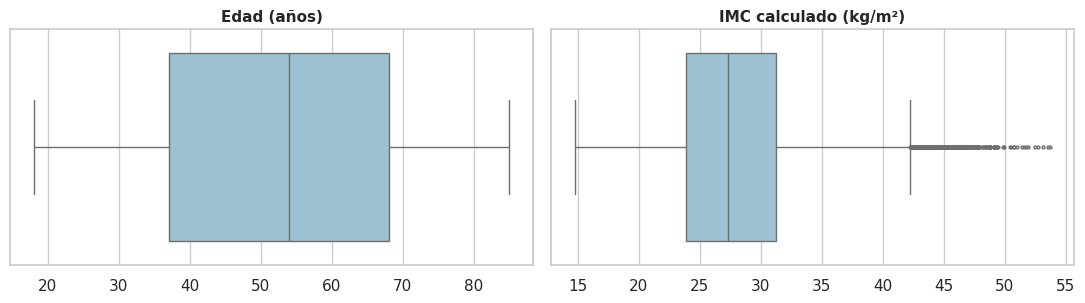

variable,mín,Q1,Q3,máx,límite inf,límite sup,outliers IQR,proporción
edad,18.0,37.0,68.0,85.0,-9.5,114.5,0,0.00%
imc,14.8,23.9,31.2,53.7,12.9,42.2,636,1.55%


Adultos con edad truncada en 85 (85 o más): 1,525 (3.40%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, var, titulo in [(axes[0], "edad", "Edad (años)"), (axes[1], "imc", "IMC calculado (kg/m²)")]:
    sns.boxplot(x=train[var], ax=ax, color="#92c5de", fliersize=2)
    ax.set_title(titulo); ax.set_xlabel("")
plt.tight_layout(); plt.show()

filas = []
for var in ["edad", "imc"]:
    x = train[var].dropna()
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filas.append([var, x.min(), q1, q3, x.max(), li, ls, ((x < li) | (x > ls)).sum(), ((x < li) | (x > ls)).mean()])
display(pd.DataFrame(filas, columns=["variable", "mín", "Q1", "Q3", "máx", "límite inf", "límite sup",
                                      "outliers IQR", "proporción"]).style.hide(axis="index")
        .format({"proporción": "{:.2%}", "mín": "{:.1f}", "Q1": "{:.1f}", "Q3": "{:.1f}", "máx": "{:.1f}",
                 "límite inf": "{:.1f}", "límite sup": "{:.1f}"}))
print(f"Adultos con edad truncada en 85 (85 o más): {(train['edad'] == 85).sum():,} ({(train['edad'] == 85).mean():.2%})")

La edad no tiene outliers según el criterio IQR. Su única particularidad es el truncamiento en 85
años (3,4 % de los adultos), impuesto por el NCHS para proteger la confidencialidad: el valor 85
significa en realidad 85 años o más, así que la variable subestima la edad de los adultos más
longevos. El IMC calculado tiene 1,55 % de outliers por encima de 42,2 kg/m², que corresponden a
obesidad severa y son valores fisiológicamente plausibles, no errores de registro. La decisión es
no eliminarlos ni recortarlos: la edad se modela con splines, lo que atenúa la influencia de los
extremos, y el IMC numérico de todas formas no entra al modelo.


### 1.9.5 Valores imposibles o inconsistentes

In [15]:
# 1) Rangos y categorías válidas
print("Edad fuera de 18-85:", ((train["edad"] < 18) | (train["edad"] > 85)).sum())
print("IMC fuera de 12-70 kg/m²:", ((train["imc"] < 12) | (train["imc"] > 70)).sum())
invalidas = {v: sorted(set(train[v].dropna()) - set(CATEGORIAS.get(v) or ORDENES.get(v)))
             for v in PREDICTORAS_CAT}
print("Categorías fuera del codebook:", {k: v for k, v in invalidas.items() if v} or "ninguna")

# 2) Consistencia entre el IMC calculado y la categoría oficial de la NHIS
cat_calc = pd.cut(train["imc"], [0, 18.5, 25, 30, 100], right=False, labels=ORDENES["imc_categoria"])
ambos = train["imc_categoria"].notna() & cat_calc.notna()
acuerdo = (cat_calc[ambos].astype(str) == train.loc[ambos, "imc_categoria"]).mean()
print(f"Acuerdo entre la categoría de IMC calculada y BMICAT_A: {acuerdo:.2%} de {ambos.sum():,} registros")
display(pd.crosstab(train.loc[ambos, "imc_categoria"], cat_calc[ambos], rownames=["BMICAT_A (NHIS)"],
                    colnames=["categoría calculada"]))

# 3) Coherencia lógica: 'nunca se siente deprimido' con diagnóstico de depresión
print("Diagnóstico de depresión pero 'nunca' se siente deprimido:",
      f"{((train['depresion_dx'] == 'Sí') & (train['frecuencia_depresion'] == 'Nunca')).mean():.2%}")

Edad fuera de 18-85: 0
IMC fuera de 12-70 kg/m²: 0
Categorías fuera del codebook: ninguna
Acuerdo entre la categoría de IMC calculada y BMICAT_A: 99.82% de 41,099 registros


categoría calculada,Bajo peso,Normal,Sobrepeso,Obesidad
BMICAT_A (NHIS),,,,
Bajo peso,402,2,0,0
Normal,0,12958,32,0
Obesidad,0,0,28,12934
Sobrepeso,0,11,14732,0


Diagnóstico de depresión pero 'nunca' se siente deprimido: 1.56%


No se encontraron valores imposibles: todas las edades están entre 18 y 85 años, todos los IMC en
rangos fisiológicos y todas las categorías corresponden a las del codebook. La categoría de IMC
calculada con peso y talla coincide con la oficial de la NHIS en el 99,8 % de los casos, y los 73
desacuerdos están todos en la frontera entre categorías contiguas, algo compatible con el redondeo
de peso y talla a libras y pulgadas enteras. El 1,6 % de los adultos con diagnóstico de depresión
dice que nunca se siente deprimido, y esto no es una inconsistencia sino lo esperable en personas en
remisión o en tratamiento. Muestra, además, que las dos variables de depresión capturan cosas
distintas: el diagnóstico histórico y los síntomas actuales.


### 1.9.6 Sesgos de muestreo y representatividad

La NHIS usa un diseño muestral complejo: cada adulto tiene un peso muestral que indica a cuántas
personas de la población representa. Comparar las proporciones sin ponderar, que es lo que ve el
modelo, con las ponderadas, que es lo que ocurre en la población real, muestra hacia dónde está
sesgada la muestra.


In [16]:
def prop(df, cond, w=None):
    return np.average(cond, weights=w)

ind = {
    "Dificultad cognitiva": train[OBJETIVO] == 1,
    "65 años o más": train["edad"] >= 65,
    "Mujer": train["sexo"] == "Mujer",
    "Blanco no hispano": train["raza_etnia"] == "Blanco no hispano",
    "Hispano": train["raza_etnia"] == "Hispano",
    "Pregrado o posgrado": train["educacion"].isin(["Pregrado", "Posgrado"]),
    "Antecedente de ACV": train["acv"] == "Sí"}
sesgo = pd.DataFrame({"sin ponderar (muestra)": {k: prop(train, v) for k, v in ind.items()},
                      "ponderada (población EE. UU.)": {k: prop(train, v, train["peso_muestral"]) for k, v in ind.items()}})
sesgo["diferencia (pp)"] = 100 * (sesgo.iloc[:, 0] - sesgo.iloc[:, 1])
display(sesgo.style.format({"sin ponderar (muestra)": "{:.2%}", "ponderada (población EE. UU.)": "{:.2%}",
                            "diferencia (pp)": "{:+.1f}"}))

,sin ponderar (muestra),ponderada (población EE. UU.),diferencia (pp)
Dificultad cognitiva,20.61%,19.44%,+1.2
65 años o más,31.79%,21.77%,+10.0
Mujer,54.52%,51.49%,+3.0
Blanco no hispano,66.08%,62.12%,+4.0
Hispano,14.51%,17.28%,-2.8
Pregrado o posgrado,38.25%,33.18%,+5.1
Antecedente de ACV,3.47%,2.63%,+0.8


La muestra sin ponderar sobrerrepresenta a los adultos de 65 años o más (31,8 % en la muestra
frente a 21,8 % en la población, unos 10 puntos de diferencia), a las personas con educación
universitaria (+5,1 pp) y a los blancos no hispanos (+4,0 pp), y subrepresenta a los hispanos
(-2,8 pp). Como la dificultad cognitiva aumenta con la edad, su prevalencia en la muestra (20,6 %)
resulta algo mayor que en la población (19,4 %). Otros sesgos de representatividad que conviene
declarar:

- Cobertura: la NHIS excluye a la población institucionalizada, como hogares de cuidado prolongado
  y prisiones, que es justo donde se concentran las personas con demencia avanzada.
- No respuesta: la tasa de respuesta de adultos fue del 47,0 % en 2023 (NCHS), y quienes no
  responden pueden diferir en salud de quienes sí lo hacen.
- Exclusión de proxies: se excluyó a quienes no podían responder por sí mismos.
- Autorreporte: los diagnósticos y las dificultades dependen de la percepción y del acceso previo a
  servicios de salud.

El modelo se entrena sin pesos muestrales, porque su objetivo es discriminar entre personas y no
estimar prevalencias poblacionales. Aun así, sus probabilidades reflejan la composición de la
muestra y no la de la población de EE. UU., lo cual queda declarado como limitación.


## 1.10 Consideraciones éticas

- Datos personales y anonimización: los archivos de uso público no contienen nombres, direcciones
  ni fechas exactas. El identificador de hogar es aleatorio y no se puede vincular entre años, y la
  geografía se limita a la región censal.
- Riesgo de reidentificación: el NCHS lo mitiga truncando la edad en 85 años, suprimiendo pesos y
  tallas extremos y agrupando categorías raras. El proyecto no añade coordenadas ni marcas de
  tiempo precisas, solo año y trimestre, y respeta la prohibición de intentar identificar a los
  participantes.
- Variables sensibles: raza y etnia se usan como variable de ajuste porque la literatura documenta
  diferencias en la exposición a factores de riesgo, pero su uso en un modelo predictivo puede
  perpetuar inequidades. En el modelo base sus coeficientes se reportan con cautela, y en entregas
  posteriores conviene evaluar el desempeño por subgrupo.
- Uso responsable del modelo: la variable objetivo es autorreportada y los datos son de EE. UU.,
  así que el modelo no es una herramienta diagnóstica ni debería aplicarse en otra población sin una
  validación local previa.
- Salud mental: el dataset incluye información sobre depresión, que se trata de forma agregada y
  sin intentar inferencias a nivel individual.
